In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("sales.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [45]:
# chronological train/test split - NOT RANDOM
train = df.iloc[:-14]       # All the data except the last 14 samples
test = df.iloc[-14:]        # The last 14 samples are in the test set

In [46]:
print(train.shape, test.shape)

(351, 1) (14, 1)


In [47]:
# Total number of training observations
n = len(train)

# The seasonal period
period = 7

# Forecast horizon. How many steps ahead we need to predict. This is equal to the length of the test set. Every forecast method needs to produce exactly h values
h = len(test)

In [48]:
print(n, period, h)

351 7 14


## Method 1 - Last Value

In [49]:
# The last value is repeated for the entire forecast
train.tail()

,sales
date,
2022-12-13,2860
2022-12-14,2710
2022-12-15,2620
2022-12-16,3700
2022-12-17,3840


In [50]:
# train["sales"].iloc[-1] gets the very last value in the training set. This is the most recent observed sales value
# np.repeat repeats the value h times (14 times). This creates an array of 14 identical values - the flat forecast
fc_last = pd.Series(
    np.repeat(train["sales"].iloc[-1], repeats=h),
    index = test.index
)

In [51]:
fc_last

date
2022-12-18    3840
2022-12-19    3840
2022-12-20    3840
2022-12-21    3840
2022-12-22    3840
2022-12-23    3840
2022-12-24    3840
2022-12-25    3840
2022-12-26    3840
2022-12-27    3840
2022-12-28    3840
2022-12-29    3840
2022-12-30    3840
2022-12-31    3840
dtype: int64

## Method 2 - Mean

In [52]:
# train['sales'].mean() — computes the arithmetic mean of all 351 training values. One single number representing the average daily sales across the entire training period.
# np.repeat(..., h) — repeats that mean value 14 times. Another flat forecast, but anchored to the historical average rather than the last value.

fc_mean = pd.Series(
    np.repeat(train["sales"].mean(), h),
    index = test.index
)

In [53]:
fc_mean

date
2022-12-18    2033.589744
2022-12-19    2033.589744
2022-12-20    2033.589744
2022-12-21    2033.589744
2022-12-22    2033.589744
2022-12-23    2033.589744
2022-12-24    2033.589744
2022-12-25    2033.589744
2022-12-26    2033.589744
2022-12-27    2033.589744
2022-12-28    2033.589744
2022-12-29    2033.589744
2022-12-30    2033.589744
2022-12-31    2033.589744
dtype: float64

## Method 3 - Seasonal naive

In [62]:
# train["sales"].iloc[-period:] --> Selects the last period rows of the training data. With period = 7, it gets the last complete week from the training data.  ".values" convert this from a pandas series to a numpy array which is required for np.tile

last_season = train["sales"].iloc[-period:].values
last_season

array([2920, 2790, 2860, 2710, 2620, 3700, 3840])

In [63]:
# h // period + 1 — integer division. With h=14 and period=7, this gives 14 // 7 + 1 = 3. This is how many times we need to tile (repeat) the 7-day pattern to guarantee we have at least 14 values. We add 1 as a safety buffer in case h is not a clean multiple of period.

# [:h] — slices off exactly the first h=14 values from the tiled array. Discards the extra values the tiling produced.


# What this block does as a whole: Copies the last complete week forward and repeats it as many times as needed to fill the forecast horizon. Next Monday is predicted to look like last Monday, next Tuesday like last Tuesday, and so on. The logic is "seasonality will repeat exactly

fc_seasonal = pd.Series(
    np.tile(last_season, h // period + 1)[:h],
    index = test.index
)

In [64]:
fc_seasonal

date
2022-12-18    2920
2022-12-19    2790
2022-12-20    2860
2022-12-21    2710
2022-12-22    2620
2022-12-23    3700
2022-12-24    3840
2022-12-25    2920
2022-12-26    2790
2022-12-27    2860
2022-12-28    2710
2022-12-29    2620
2022-12-30    3700
2022-12-31    3840
dtype: int64

## Method 4 - Drift

In [68]:
train["sales"].head(1)

date
2022-01-01    1200
Name: sales, dtype: int64

In [67]:
train["sales"].tail(1)

date
2022-12-17    3840
Name: sales, dtype: int64

In [73]:
# train['sales'].iloc[-1] — last training value (most recent).
# train['sales'].iloc[0] — first training value (oldest).

# (last - first) / (n - 1) — total change across the training period divided by the number of steps. This is the average change per step — the slope of the line connecting the first and last observation. With n=351 observations, if sales went from 1200 to 3840 over that period, drift = (3840-1200)/350 ≈ 7.54 dollars per day.

drift = (train["sales"].iloc[-1] - train["sales"].iloc[0]) / (n - 1)
print(drift)

7.542857142857143


In [76]:
# [train['sales'].iloc[-1] + (i+1) * drift for i in range(h)] — a list comprehension that generates 14 forecast values. For each step i from 0 to 13:
fc_drift = pd.Series(
    [train["sales"].iloc[-1] + (i+1) * drift for i in range(h)],       # range(14)  --> 0 till 13
    index = test.index
)


# What this block does as a whole: Draws a straight line from the first to the last training observation and extends it forward. The logic is "the average rate of change observed historically will continue."

In [81]:
fc_drift

date
2022-12-18    3847.542857
2022-12-19    3855.085714
2022-12-20    3862.628571
2022-12-21    3870.171429
2022-12-22    3877.714286
2022-12-23    3885.257143
2022-12-24    3892.800000
2022-12-25    3900.342857
2022-12-26    3907.885714
2022-12-27    3915.428571
2022-12-28    3922.971429
2022-12-29    3930.514286
2022-12-30    3938.057143
2022-12-31    3945.600000
dtype: float64

In [89]:
# MAE helper - defines a reusable function that takes two arguments: the forecast Series and the actual test Series.
def mae(forecast, actual):
    return np.round(np.mean(np.abs(forecast.values - actual.values)), 2)

In [91]:
maes = {
    'Last value'     : mae(fc_last, test['sales']),
    'Mean'           : mae(fc_mean, test['sales']),
    'Seasonal naive' : mae(fc_seasonal, test['sales']),
    'Drift'          : mae(fc_drift, test['sales']),
}
maes

# What this block does as a whole: Gives you a single comparable number for each method. The method with the lowest MAE performed best on this particular test period. This is your baseline — every more complex model you build later must produce a lower MAE than the best naive method to be worth using.

{'Last value': np.float64(674.29),
 'Mean': np.float64(1249.27),
 'Seasonal naive': np.float64(254.29),
 'Drift': np.float64(714.69)}

## Plot

In [92]:
forecasts = [
    (fc_last,     'Last value',
     '#1D9E75',
     'Repeats the last observed value as a flat line.\n'
     'Logic: the best guess for tomorrow is today.\n'
     'Works for: random walk series (e.g. stock prices short-term).'),

    (fc_mean,     'Mean',
     '#378ADD',
     'Repeats the historical average as a flat line.\n'
     'Logic: the series always returns to its long-run mean.\n'
     'Works for: stationary series with no trend or seasonality.'),

    (fc_seasonal, 'Seasonal naive',
     '#7F77DD',
     'Copies values from the same position in the last season.\n'
     'Logic: next Monday looks like last Monday.\n'
     'Works for: series with strong seasonality, no trend.'),

    (fc_drift,    'Drift',
     '#D85A30',
     'Extends a line from first to last observation into the future.\n'
     'Logic: the average rate of change will continue.\n'
     'Works for: series with a clear linear trend.'),
]

# Show only last 30 days of train so the chart is not too compressed
train_plot = train['sales'].iloc[-30:]

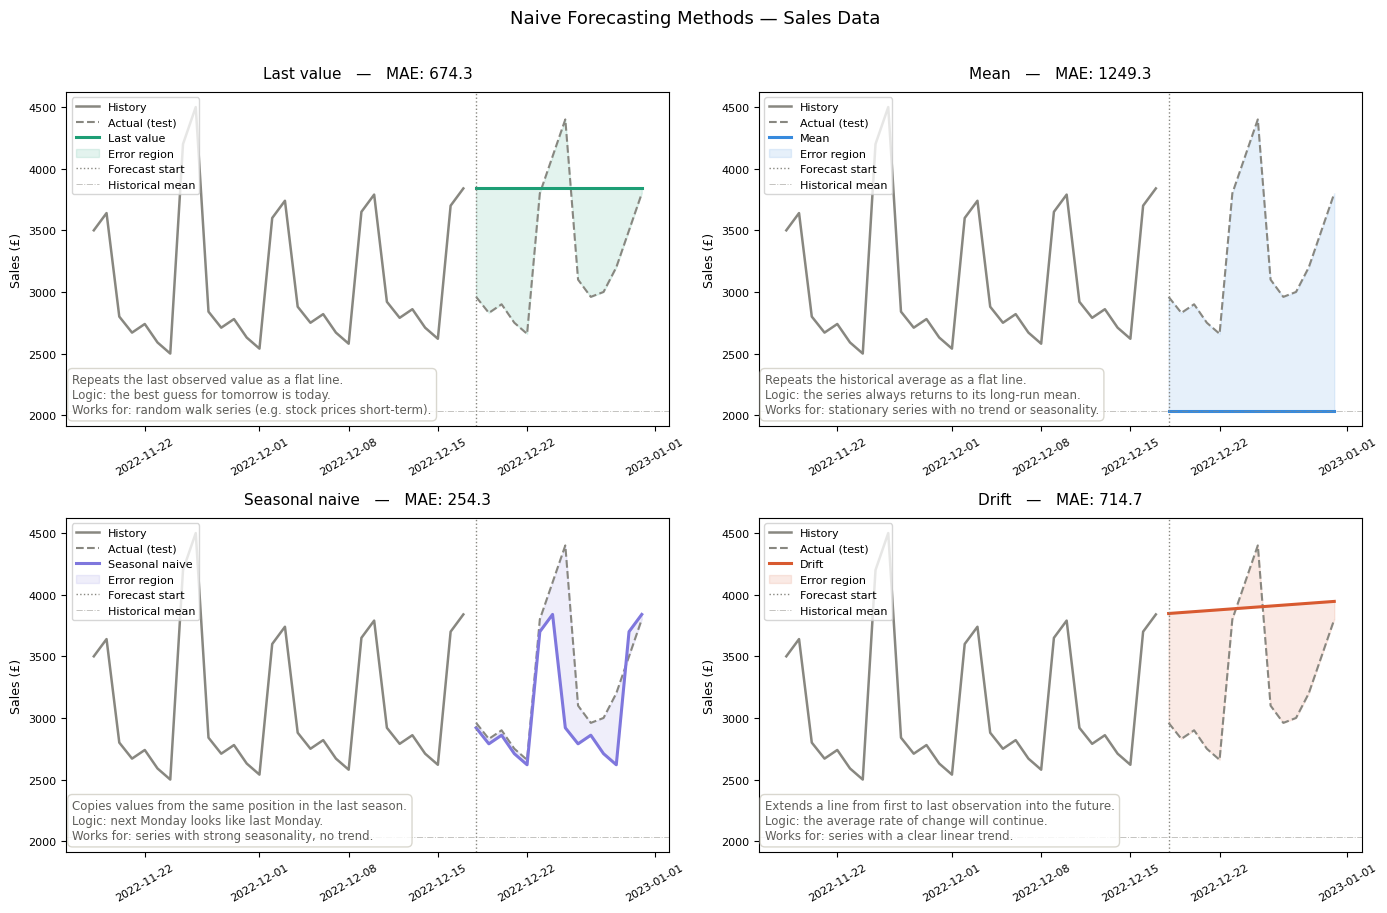

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# subplots(2, 2) returns a 2D array of axes: [[ax[0], ax[1]], [ax[2], ax[3]].  .flatten() converts it into 1D array [ax[0], ax[1], ax[2], ax[3]] which is later helpful when looping
axes = axes.flatten()

for ax, (fc, name, color, explanation) in zip(axes, forecasts):

    # History line
    ax.plot(train_plot.index, train_plot.values,
            color='#888780', linewidth=1.8, label='History')

    # Actual future values (ground truth)
    ax.plot(test.index, test['sales'].values,
            color='#888780', linewidth=1.5, linestyle='--',
            label='Actual (test)')

    # Forecast line
    ax.plot(fc.index, fc.values,
            color=color, linewidth=2.2, label=f'{name}')

    # Shaded error region between forecast and actual
    ax.fill_between(test.index,
                    fc.values,
                    test['sales'].values,
                    alpha=0.12, color=color,
                    label='Error region')

    # Vertical line marking where forecast starts ──────────────────────────
    ax.axvline(test.index[0],
               color='#888780', linewidth=1.0,
               linestyle=':', label='Forecast start')

    # ── Horizontal mean reference line (helps see if forecast is biased) ─────
    ax.axhline(train['sales'].mean(),
               color='#888780', linewidth=0.7,
               linestyle='-.', alpha=0.5, label='Historical mean')

    # Title with MAE score
    ax.set_title(f'{name}   —   MAE: {maes[name]:.1f}',
                 fontsize=11, fontweight='500', pad=10)

    # Explanation as text box inside the plot
    ax.text(0.01, 0.03, explanation,
            transform=ax.transAxes,
            fontsize=8.5,
            verticalalignment='bottom',
            color='#5F5E5A',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white',
                      edgecolor='#D3D1C7',
                      alpha=0.85))

    ax.set_ylabel('Sales (£)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='both', labelsize=8)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Naive Forecasting Methods — Sales Data',
             fontsize=13, fontweight='500', y=1.01)

plt.tight_layout()
plt.savefig('naive_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# Grey solid line — History. The last 30 days of training data. Showing only 30 days instead of the full 351 keeps the chart readable — enough context to see the recent trend and seasonality without compressing the forecast period into a tiny sliver on the right.

# Grey dashed line — Actual (test). The real future values the model never saw. This is your ground truth. Every forecast is judged against this line — the closer your coloured line tracks this, the better.

# Coloured solid line — Forecast. Each method's prediction for the 14-day test period. The colour matches the method so all four panels are visually distinct at a glance.

# Shaded region between forecast and actual — Error region. The gap between what was predicted and what actually happened, filled with a transparent colour. Wide shading = large errors. Narrow shading = accurate forecast. This makes the error visible without needing to read numbers.

# Vertical dotted line — Forecast start. Marks the exact point where history ends and the forecast begins. Without this line the eye can lose track of where real data stops and predictions start.

# Horizontal dash-dot line — Historical mean. A reference line at the training mean. Useful for spotting bias — if the forecast consistently sits above or below this line relative to the actual values, the method is systematically over or underpredicting.

# Text box — Explanation. Three lines inside each subplot: what the method does, the logic behind it, and when it works best. This means the chart is self-contained — anyone reading it without notes can understand all four methods just from the plot.

# Title with MAE — MAE: X.X. The error score is embedded directly in the subplot title so you can compare all four methods at a glance without looking at a separate table.